<a href="https://colab.research.google.com/github/Lea17-hub/camera-optics-lab/blob/main/02_defocus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Defocus

## Question

How does defocus change the point spread function and the final image?

In [10]:
# Baseline optical system
N = 512
BASE_RADIUS = 0.35

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from PIL import Image

In [12]:
def make_defocused_psf(radius=BASE_RADIUS, defocus=0.0, N=512):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    phase = np.exp(1j * defocus * R**2)

    pupil = aperture * phase

    field = np.fft.fftshift(np.fft.fft2(pupil))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return psf

In [19]:

psf_focus = make_defocused_psf(
    radius=BASE_RADIUS,
    defocus=0
)

psf_defocus = make_defocused_psf(
    radius=BASE_RADIUS,
    defocus=50
)

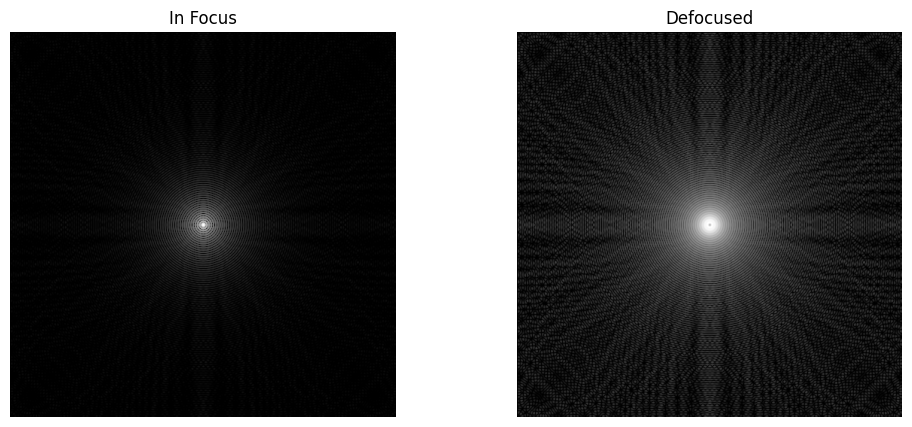

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.log10(psf_focus + 1e-6), cmap="gray")
plt.title("In Focus")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.log10(psf_defocus + 1e-6), cmap="gray")
plt.title("Defocused")
plt.axis("off")

plt.show()

In [21]:
def blur_with_psf(img, psf, crop=81):
    center = psf.shape[0] // 2
    half = crop // 2

    kernel = psf[
        center-half:center+half+1,
        center-half:center+half+1
    ]

    kernel = kernel / kernel.sum()

    return fftconvolve(img, kernel, mode="same")

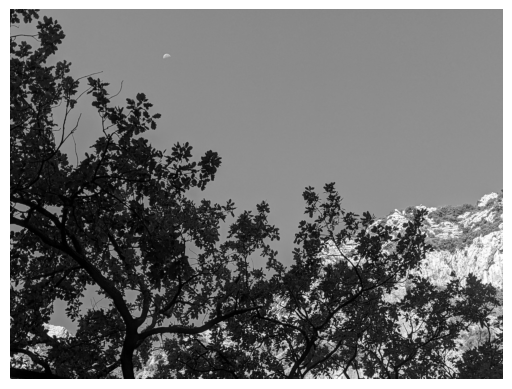

In [22]:
from PIL import Image
import numpy as np

img = Image.open("1000052418.jpg").convert("L")
img = np.array(img) / 255.0

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [23]:
blur_focus = blur_with_psf(img, psf_focus)
blur_defocus = blur_with_psf(img, psf_defocus)

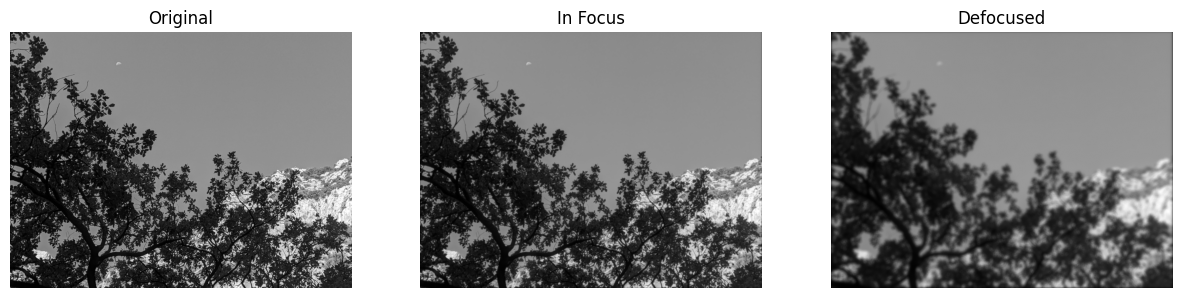

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_focus, cmap="gray")
plt.title("In Focus")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_defocus, cmap="gray")
plt.title("Defocused")
plt.axis("off")

plt.show()

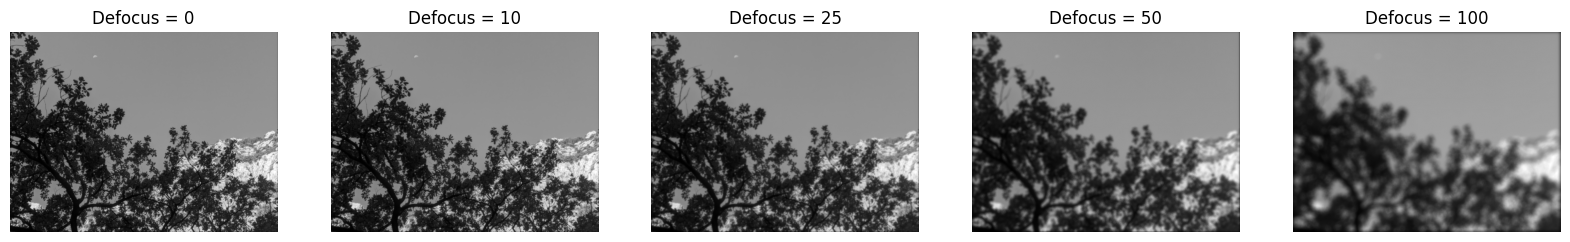

In [26]:
defocus_values = [0, 10, 25, 50, 100]

plt.figure(figsize=(20, 4))

for i, d in enumerate(defocus_values):

    psf_d = make_defocused_psf(
        radius=BASE_RADIUS,
        defocus=d
    )

    blur_d = blur_with_psf(img, psf_d)

    plt.subplot(1, 5, i + 1)
    plt.imshow(blur_d, cmap="gray")
    plt.title(f"Defocus = {d}")
    plt.axis("off")

plt.savefig("defocus_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

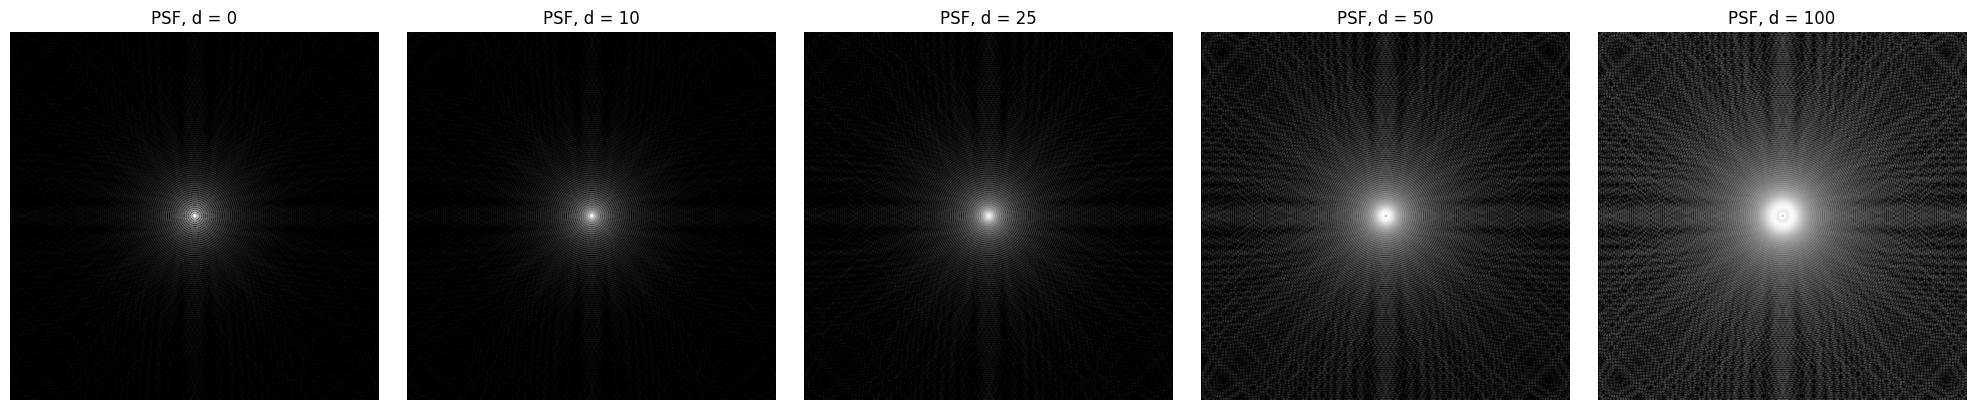

In [28]:
defocus_values = [0, 10, 25, 50, 100]

plt.figure(figsize=(20, 4))

for i, d in enumerate(defocus_values):
    psf_d = make_defocused_psf(
        radius=BASE_RADIUS,
        defocus=d
    )

    plt.subplot(1, len(defocus_values), i + 1)
    plt.imshow(np.log10(psf_d + 1e-6), cmap="gray")
    plt.title(f"PSF, d = {d}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("defocus_psf_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
defocus_values = [0, 10, 25, 50, 100]

# baseline: in-focus image
psf_focus = make_defocused_psf(
    radius=BASE_RADIUS,
    defocus=0
)

img_focus = blur_with_psf(img, psf_focus)

mse_values = []

for d in defocus_values:
    psf_d = make_defocused_psf(
        radius=BASE_RADIUS,
        defocus=d
    )

    img_d = blur_with_psf(img, psf_d)

    mse = np.mean((img_focus - img_d)**2)
    mse_values.append(mse)

print(mse_values)

[np.float64(0.0), np.float64(4.982480074318672e-05), np.float64(0.00125948501324193), np.float64(0.005611965103070642), np.float64(0.00999918593989045)]


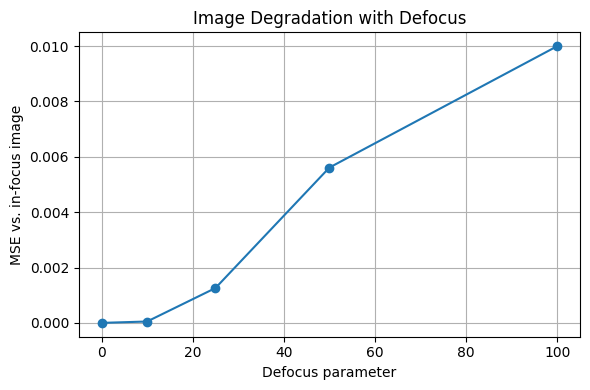

In [30]:
plt.figure(figsize=(6, 4))

plt.plot(defocus_values, mse_values, marker="o")

plt.xlabel("Defocus parameter")
plt.ylabel("MSE vs. in-focus image")
plt.title("Image Degradation with Defocus")

plt.grid(True)
plt.tight_layout()

plt.savefig("defocus_mse.png", dpi=300, bbox_inches="tight")
plt.show()